# Differentiable Polyhedral Gravity — PyTorch Interface

`polyhedral_gravity.torch` is a pure-Python, GPU-capable, autodiff-friendly reimplementation of the Tsoulis (2012) analytic formula. It evaluates the same gravitational potential and acceleration as the C++ `evaluate`, but lets you **differentiate through it**, enabling gradient-based applications such as gravity inversion and shape estimation from spacecraft measurements.

Use the PyTorch interface when you need gradients. For pure forward evaluation the C++ implementation is faster.

## Installation

```bash
pip install polyhedral-gravity torch
```

In [1]:
import sys
sys.path.insert(0, '../script')

import numpy as np
import torch
import mesh_plotting

from polyhedral_gravity import Polyhedron, evaluate, PolyhedronIntegrity
from polyhedral_gravity.torch import evaluate as torch_evaluate

import mesh_plotting

print(f"torch {torch.__version__}  |  CUDA: {torch.cuda.is_available()}")

torch 2.12.0+cu130  |  CUDA: True


## 1 — Basic usage

We use the unit cube from the rest of the documentation: 8 vertices at (+-1, +-1, +-1), 12 triangular faces, outward normals.

In [2]:
cube_vertices = np.array([
    [-1, -1, -1], [1, -1, -1], [1,  1, -1], [-1,  1, -1],
    [-1, -1,  1], [1, -1,  1], [1,  1,  1], [-1,  1,  1],
])

cube_faces = np.array([
    [1, 3, 2], [0, 3, 1], [0, 1, 5], [0, 5, 4],
    [0, 7, 3], [0, 4, 7], [1, 2, 6], [1, 6, 5],
    [2, 3, 6], [3, 7, 6], [4, 5, 6], [4, 6, 7],
])

density = 1.0  # kg/m^3

verts_t = torch.tensor(cube_vertices, dtype=torch.float64)
faces_t = torch.tensor(cube_faces,    dtype=torch.long)
pts_t   = torch.tensor([[2.5, 2.5, 2.5]], dtype=torch.float64)

potential, acceleration, tensor = torch_evaluate(verts_t, faces_t, density, pts_t)

print(f"Potential:    {potential.item():.6e} m^2/s^2")
print(f"Acceleration: {acceleration.squeeze().tolist()} m/s^2")

Potential:    1.233669e-10 m^2/s^2
Acceleration: [-1.648068951904784e-11, -1.648068951904784e-11, -1.648068951904783e-11] m/s^2


### Comparing with the C++ reference

Both interfaces implement the same Tsoulis (2012) formula and should agree to machine precision.

In [3]:
polyhedron = Polyhedron(
    polyhedral_source=(cube_vertices, cube_faces),
    density=density,
    integrity_check=PolyhedronIntegrity.DISABLE,
)

V_cpp, g_cpp, T_cpp = evaluate(polyhedron, pts_t[0].numpy())

rel_err_V = abs(V_cpp - potential.item()) / abs(V_cpp)
rel_err_g = np.linalg.norm(np.array(g_cpp) - acceleration.numpy()) / np.linalg.norm(g_cpp)

print(f"C++ potential:   {V_cpp:.6e}")
print(f"Torch potential: {potential.item():.6e}")
print(f"Relative error (potential):    {rel_err_V:.2e}")
print(f"Relative error (acceleration): {rel_err_g:.2e}")

C++ potential:   1.233669e-10
Torch potential: 1.233669e-10
Relative error (potential):    6.29e-16
Relative error (acceleration): 1.76e-15


### Gradient tensor

The third return value is the gravity gradient tensor `[Vxx, Vyy, Vzz, Vxy, Vxz, Vyz]` in 1/s².

In [4]:
rel_err_T = np.linalg.norm(np.array(T_cpp) - tensor.numpy()) / np.linalg.norm(T_cpp)

print("Gradient tensor [Vxx, Vyy, Vzz, Vxy, Vxz, Vyz] [1/s^2]:")
print(f"  C++:   {[f'{v:.4e}' for v in T_cpp]}")
print(f"  Torch: {[f'{v:.4e}' for v in tensor.squeeze().tolist()]}")
print(f"  Relative error: {rel_err_T:.2e}")

Gradient tensor [Vxx, Vyy, Vzz, Vxy, Vxz, Vyz] [1/s^2]:
  C++:   ['-1.1115e-26', '-1.1115e-26', '-1.1115e-26', '6.6252e-12', '6.6252e-12', '6.6252e-12']
  Torch: ['3.7050e-27', '3.7050e-27', '3.7050e-27', '6.6252e-12', '6.6252e-12', '6.6252e-12']
  Relative error: 7.07e-15


## 2 — Multiple computation points

`polyhedral_gravity.torch` evaluates all Q points in a single vectorised pass, rather than looping over points as the C++ interface does.

In [5]:
rng = np.random.default_rng(42)
pts_np = rng.standard_normal((500, 3))
pts_np /= np.linalg.norm(pts_np, axis=1, keepdims=True)
pts_np *= 10.0

pts_batch = torch.tensor(pts_np, dtype=torch.float64)
V_batch, g_batch, _ = torch_evaluate(verts_t, faces_t, density, pts_batch)

print(f"Evaluated {pts_batch.shape[0]} points")
print(f"Potential range: [{V_batch.min():.4e}, {V_batch.max():.4e}]")

Evaluated 500 points
Potential range: [5.3393e-11, 5.3395e-11]


## Visualising the potential field

A 2D sweep over the $z=0$ plane lets us see both the potential and the acceleration field at a glance.

Plotting Grid 2D


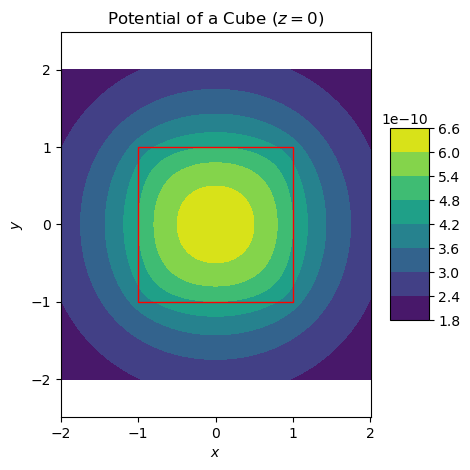

In [6]:
VALUES = np.arange(-2, 2.01, 0.005)
grid_pts = np.array(np.meshgrid(VALUES, VALUES, [0])).T.reshape(-1, 3)
grid_t = torch.tensor(grid_pts, dtype=torch.float64)

V_grid, _, __ = torch_evaluate(verts_t, faces_t, density, grid_t)
potentials = V_grid.detach().numpy()

X = grid_pts[:, 0].reshape(len(VALUES), -1)
Y = grid_pts[:, 1].reshape(len(VALUES), -1)

mesh_plotting.plot_grid_2d(X, Y, potentials, "Potential of a Cube ($z=0$)", plot_rectangle=True)

Plotting Quiver


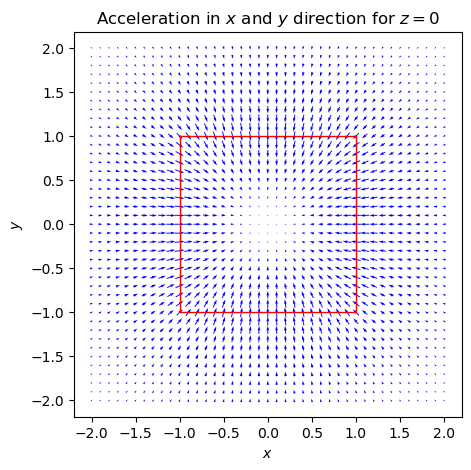

In [7]:
VALUES_Q = np.arange(-2, 2.01, 0.1)
grid_q = np.array(np.meshgrid(VALUES_Q, VALUES_Q, [0])).T.reshape(-1, 3)
grid_q_t = torch.tensor(grid_q, dtype=torch.float64)

_, g_grid, __ = torch_evaluate(verts_t, faces_t, density, grid_q_t)
acc_xy = g_grid.detach().numpy()[:, :2]

X_q = grid_q[:, 0].reshape(len(VALUES_Q), -1)
Y_q = grid_q[:, 1].reshape(len(VALUES_Q), -1)

mesh_plotting.plot_quiver(X_q, Y_q, acc_xy, "Acceleration in $x$ and $y$ direction for $z=0$", plot_rectangle=True)

## 3 — Autodiff: gradients with respect to vertex positions

Setting `requires_grad=True` on any input tensor lets PyTorch's autograd engine propagate gradients back through the entire Tsoulis computation

In [8]:
verts_grad = verts_t.clone().requires_grad_(True)

V, _, __ = torch_evaluate(verts_grad, faces_t, density, pts_t)
V.backward()

print("dV/d(vertices):")
print(verts_grad.grad)

dV/d(vertices):
tensor([[ 3.5206e-10,  3.5206e-10, -8.0713e-12],
        [-2.8557e-11, -3.7792e-10, -1.7782e-11],
        [ 6.1536e-11,  6.1536e-11, -9.8485e-12],
        [-3.7792e-10, -2.8557e-11, -1.7782e-11],
        [-3.7792e-10, -3.7792e-10, -2.8557e-11],
        [ 6.1536e-11,  3.5029e-10,  6.1536e-11],
        [-2.4551e-11, -2.4551e-11, -2.4551e-11],
        [ 3.5029e-10,  6.1536e-11,  6.1536e-11]], dtype=torch.float64)


## 4 — Autodiff: gradients with respect to density

In [9]:
rho = torch.tensor(1.0, dtype=torch.float64, requires_grad=True)
V, _, __ = torch_evaluate(verts_t, faces_t, rho, pts_t)
V.backward()

print(f"dV/d(rho) = {rho.grad.item():.6e}")

dV/d(rho) = 1.233669e-10


## 5 — GPU acceleration

In [10]:
if torch.cuda.is_available():
    device = "cuda"
    V_gpu, g_gpu, _ = torch_evaluate(
        verts_t.to(device), faces_t.to(device), density, pts_batch.to(device)
    )
    print(f"GPU potential mean: {V_gpu.mean():.6e}")
    print(f"Max diff vs CPU:    {(V_gpu.cpu() - V_batch).abs().max():.2e}")
else:
    print("No CUDA device available.")

GPU potential mean: 5.339437e-11
Max diff vs CPU:    6.09e-24
